In [1]:
import numpy as np
import sys
import os
import torch
# add parent folder (production) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from utils.LoRa import LoRa
from utils.bam import MultiBAMv3

import importlib
import utils.my_lora_utils
importlib.reload(utils.my_lora_utils)
from utils.my_lora_utils import *

print(utils.my_lora_utils.__file__)

c:\Users\priba\Sean-2025\INC-LAB\BAM\INC-BAM\utils\my_lora_utils.py


In [2]:
sf = 9
bw = 125000
fs = 1_000_000
lora_init = LoRa(sf, bw)
input_row = 512
input_col = 33
## HOW TO LOAD WEIGHT
layers = [input_col * input_row, 1024, 256] # <-- must match training

multi_bam = MultiBAMv3(layers_dims=layers, eta=1e-5)

for i, bam in enumerate(multi_bam.bams):
    w_np = np.load(f"weight_{input_row*input_col}_1024_256/weights_layer_{i}.npy")
    bam.W = torch.tensor(w_np, dtype=torch.float32, device=bam.device)
    print(f"Loaded layer {i}: shape {bam.W.shape}")


Loaded layer 0: shape torch.Size([1024, 16896])
Loaded layer 1: shape torch.Size([256, 1024])


c:\Users\priba\Sean-2025\INC-LAB\BAM\INC-BAM\utils\bam.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X, dtype=torch.float32, device=self.device)


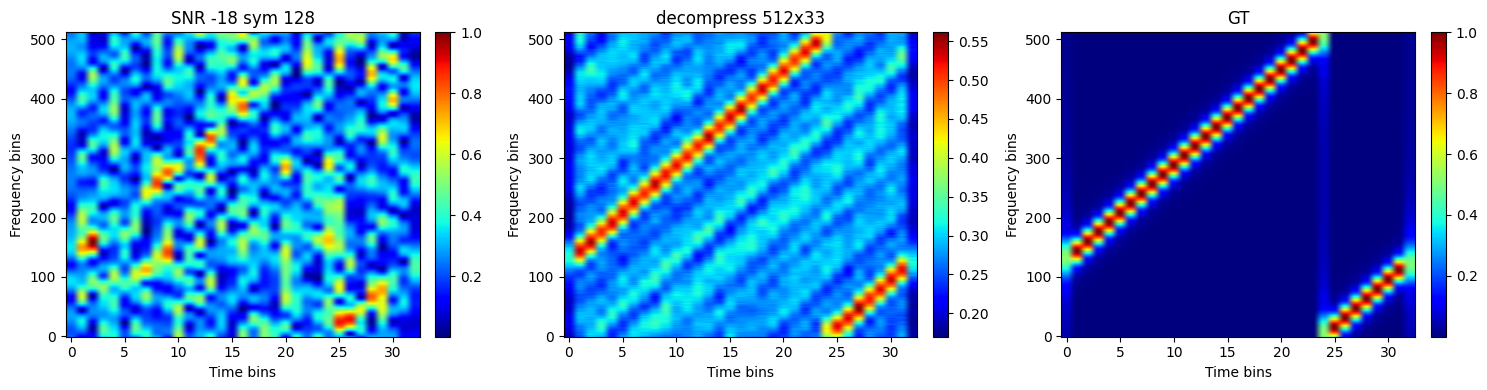

In [3]:
symbol1 = 128
seed = 26
x1 = lora_init.gen_symbol_fs(symbol1, sf=sf, bw=bw, Fs=fs)  # you had Fs=int(bw*8)=1e6
snr = -18

gt_ds,fs_new_gt = downsampling(x1,fs,4)
gt = create_spectrogram_from_torch(gt_ds,sf,bw,fs_new_gt,input_row,input_col,0,0,0,None)

x = lora_init.awgn_iq_with_seed(x1,snr,seed)
#### PREPROCESS : DOWNSAMPLING ########
x_ds,fs_new = downsampling(x,fs,4)

#### STEP 2 Create Spectrogram ########
spec_ = create_spectrogram_from_torch(x_ds,sf,bw,fs_new,input_row,input_col,0,0,0,None)

#### STEP 3 FLATTEN INPUT ########
flat = spec_.flatten().reshape(1, -1) # BEFORE COMPRESS MUST 
compress_ = multi_bam.compress(flat)
decompress_ = multi_bam.decompress(compress_)

#### STEP 4 AFTER DECOMPRESS RESHAPE to INITIAL SHAPE ########
reco_flat = decompress_.reshape(-1)  # AFTER DECOMPRESS MUST
reco_spec = reco_flat.reshape(input_row, input_col)

array_a = [spec_,reco_spec,gt]

show_multiple_spectrograms(array_a,[f'SNR {snr} sym {symbol1}',f"decompress {input_row}x{input_col}","GT"],3)


In [5]:

!pip freeze > requirements.txt